<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/normal_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

print("✅ All libraries imported!")

✅ All libraries imported!


In [4]:
# Change this path according to your Drive folder
df = pd.read_csv('/content/drive/MyDrive/Dataset/continuous dataset.csv')   # <-- yahan apna exact path daal do

# Datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Basic features
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_holiday'] = df['holiday']

# Lag features
df['lag_1'] = df['nat_demand'].shift(1)
df['lag_24'] = df['nat_demand'].shift(24)
df['lag_168'] = df['nat_demand'].shift(168)
df['rolling_mean_24'] = df['nat_demand'].rolling(window=24).mean()

df = df.dropna().reset_index(drop=True)

print("✅ Data loaded and features created!")
print("Shape:", df.shape)

✅ Data loaded and features created!
Shape: (47880, 26)


In [5]:
# Peak definition
peak_threshold = df['nat_demand'].quantile(0.90)
df['is_peak'] = (df['nat_demand'] > peak_threshold).astype(int)

feature_columns = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday',
                   'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
                   'T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
                   'T2M_san','QV2M_san','TQL_san','W2M_san',
                   'T2M_dav','QV2M_dav','TQL_dav','W2M_dav']

X = df[feature_columns]
y = df['nat_demand']

# Time-based split
train_size = int(len(df) * 0.80)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]
peak_test_mask = df['is_peak'].iloc[train_size:].values

print("✅ Train-Test Split Done!")
print("Train:", len(X_train), "Test:", len(X_test))

✅ Train-Test Split Done!
Train: 38304 Test: 9576


In [7]:
# ====================== STEP 4 ======================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # Fixed RMSE calculation
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))   # <-- Yeh line fix ki
    mape = (abs(y_test - pred) / y_test).mean() * 100

    # Peak error
    peak_pred = pred[peak_test_mask == 1]
    peak_actual = y_test[peak_test_mask == 1]
    peak_mape = (abs(peak_actual - peak_pred) / peak_actual).mean() * 100 if len(peak_actual) > 0 else 0

    results[name] = {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'Peak MAPE (%)': round(peak_mape, 2)
    }

    print(f"{name} done.")

# Results Table
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("FINAL RESULTS TABLE")
print("="*60)
print(results_df)

best_model_name = results_df['Peak MAPE (%)'].idxmin()
print(f"\n🏆 Best Model for Peak Forecasting: {best_model_name}")

Training models...

Training Linear Regression...
Linear Regression done.
Training Random Forest...
Random Forest done.
Training XGBoost...
XGBoost done.
Training KNN...
KNN done.

FINAL RESULTS TABLE
                     MAE   RMSE  MAPE (%)  Peak MAPE (%)
Linear Regression  34.03  44.00      2.81           2.52
Random Forest      19.23  27.10      1.61           1.34
XGBoost            18.50  25.67      1.55           1.34
KNN                31.89  44.48      2.65           2.32

🏆 Best Model for Peak Forecasting: Random Forest



Best Model: Random Forest


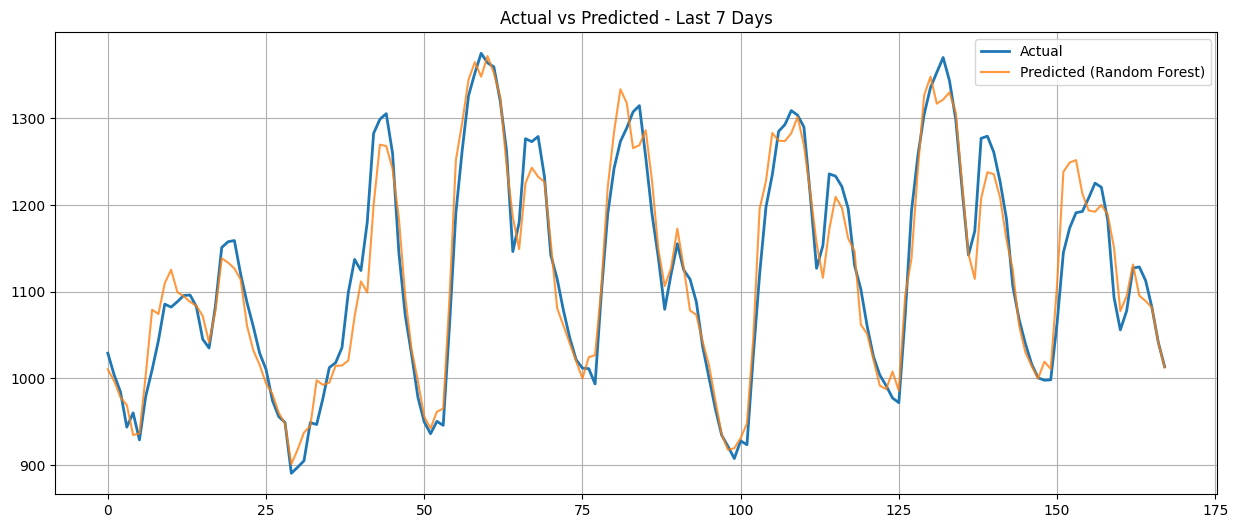

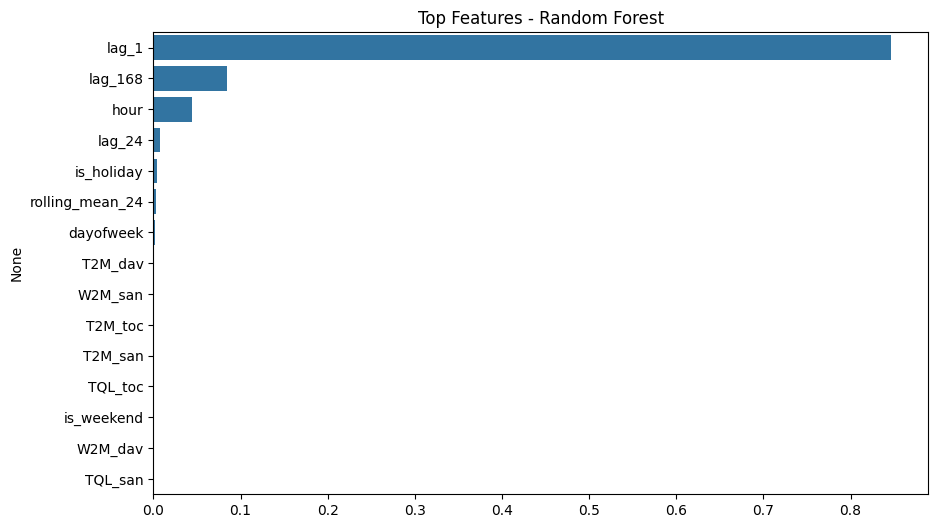

In [8]:
best_name = min(results, key=lambda x: results[x]['Peak MAPE (%)'])
best_model = models[best_name]
best_pred = best_model.predict(X_test)

print(f"\nBest Model: {best_name}")

# Plot
plt.figure(figsize=(15,6))
last = 168
plt.plot(y_test.iloc[-last:].values, label='Actual', linewidth=2)
plt.plot(best_pred[-last:], label=f'Predicted ({best_name})', alpha=0.8)
plt.title('Actual vs Predicted - Last 7 Days')
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance
if best_name in ["Random Forest", "XGBoost"]:
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10,6))
    sns.barplot(x=imp.values, y=imp.index)
    plt.title(f'Top Features - {best_name}')
    plt.show()